### ToDo

1. Apply Filter on Gross Area in BuildingValueperSQFT Query



In [1]:
import pandas
from sqlalchemy import create_engine
import re
from datetime import datetime
from glob import glob
import os
import urllib
from tqdm.notebook import tqdm
from datetime import datetime
from importlib import import_module, reload
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
os.chdir("Y:/Code/CROWN ANALYTICS/Data Quality")

In [3]:
inputfile_path = "Y:\Code\Crown Analytics\Data Quality\DataFiles\Inputfile for DataQuality.xlsx"
pivotfile_path = "Y:\Code\Crown Analytics\Data Quality\DataFiles\Data Quality wPivot_2023_.xlsx"
datafile_path = "Y:\Code\Crown Analytics\Data Quality\DataFiles\Data Quality_2023_CA_EQ.xlsx"

In [4]:
# from sql_queries import queries, sql_exposureSetSID
sql_queries = import_module("sql_queries")
reload(sql_queries)
queries = getattr(sql_queries, "queries")
sql_exposureSetSID = getattr(sql_queries, "sql_exposureSetSID")
from db_connection import get_engine

In [5]:
db_v9prd_config = dict(
DRIVER_NAME = "{SQL Server}",
SERVER_NAME = "sqlprdair",
DB_NAME = "AIRProject",
USERNAME = "ARAPL_USR",
PASSWORD = "Arapl@123"
)
db_v9stg_config = dict(
DRIVER_NAME = "{SQL Server}",
SERVER_NAME = "sqlbtaair",
DB_NAME = "AIRProject",
USERNAME = "ARAPL_USR",
PASSWORD = "Arapl@123"
)
db_v10_config = dict(
DRIVER_NAME = "{SQL Server}",
SERVER_NAME = "clv235dw-bbee4d",
DB_NAME = "AIRProject",
USERNAME = "ARAPL_USR",
PASSWORD = "Arapl@123"
)

In [6]:
engines = {"v9_prd": get_engine(**db_v9prd_config),
           "v9_stg": get_engine(**db_v9stg_config),
           "v10": get_engine(**db_v10_config)
          }

engines

{'v9_prd': Engine(mssql+pyodbc:///?odbc_connect=DRIVER={SQL Server};SERVER=sqlprdair;DATABASE=AIRProject;UID=ARAPL_USR;PWD=Arapl@123),
 'v9_stg': Engine(mssql+pyodbc:///?odbc_connect=DRIVER={SQL Server};SERVER=sqlbtaair;DATABASE=AIRProject;UID=ARAPL_USR;PWD=Arapl@123),
 'v10': Engine(mssql+pyodbc:///?odbc_connect=DRIVER={SQL Server};SERVER=clv235dw-bbee4d;DATABASE=AIRProject;UID=ARAPL_USR;PWD=Arapl@123)}

In [7]:
# # Create New Excel sheet if not exist

# if not os.path.exists(datafile_path):
#     print("Created Data New File")
#     open(datafile_path, 'a')


# if not os.path.exists(pivotfile_path):
#     print("Created Pivot File")
#     open(pivotfile_path, 'a')
    
# datafile_writer = pandas.ExcelWriter(datafile_path, engine='openpyxl')
# pivot_writer = pandas.ExcelWriter(pivotfile_path, engine='openpyxl')


In [8]:
# ZipCodeList = "33023,33054,33415,33966,34243,33584,32707,32812"

In [9]:
# Input Data from Excel File
input_df = pandas.read_excel(inputfile_path, sheet_name=1)
input_df

,Sponsor Name,CEDE Name,Exposure Set Name,Exposure Set SID,Version,Sheet Name
0,2023 Oklahoma Farm,WRe_OKFB_20220630_TSv9_TSE,Combined,2,v10,costperSQFT
1,2023 Celina,AIRExp_Celina_Jun2022_ForRe_TSv9,Celina WIND,7,v10,costperSQFT
2,2023 Quincy,AIRExp_QuincyMutual_2023_HU_SCS_WT_ForRe,ES_Quincy_Aug2022_HU,2,v10,costperSQFT
3,2023 Progressive Agg,AJGRe_PGRHome_Proj20230831_v3_xEQSH_AggRenewal...,WT_WF_FF-Proj20230831,8,v10,costperSQFT
4,2023 West Bend,AIRExp_WestBend_20220630_forRe_TS9,ES_WBMIC_NonAuto_WindFire,3,v10,costperSQFT
5,2023 American Family,AmericanFamily_202206_AIRv9_OWWT_Prop_MKT_AIRExp,Homesite_202206_OWWT,19,v10,costperSQFT
6,2023 Hartford,Hartford_202206_EQFFSL,2023_Hartford_EQFFSL_Combined,"1,2,3,4,5,6,7,8,9",v10,costperSQFT
7,2023 Central Mutual,AIRExp_CentralMutual_20220831_v9_Proforma_ForRe,TS_PWA,3,v10,costperSQFT
8,2023 Erie,AIRExp_Erie_20220331_xAddress_re,ES_Erie_20220331_Prop_HU,5,v10,costperSQFT


In [10]:
input_df[['Sposor Year', 'Sponsor']] = input_df["Sponsor Name"].str.split(" ", 1, expand=True)

In [11]:
input_df

,Sponsor Name,CEDE Name,Exposure Set Name,Exposure Set SID,Version,Sheet Name,Sposor Year,Sponsor
0,2023 Oklahoma Farm,WRe_OKFB_20220630_TSv9_TSE,Combined,2,v10,costperSQFT,2023,Oklahoma Farm
1,2023 Celina,AIRExp_Celina_Jun2022_ForRe_TSv9,Celina WIND,7,v10,costperSQFT,2023,Celina
2,2023 Quincy,AIRExp_QuincyMutual_2023_HU_SCS_WT_ForRe,ES_Quincy_Aug2022_HU,2,v10,costperSQFT,2023,Quincy
3,2023 Progressive Agg,AJGRe_PGRHome_Proj20230831_v3_xEQSH_AggRenewal...,WT_WF_FF-Proj20230831,8,v10,costperSQFT,2023,Progressive Agg
4,2023 West Bend,AIRExp_WestBend_20220630_forRe_TS9,ES_WBMIC_NonAuto_WindFire,3,v10,costperSQFT,2023,West Bend
5,2023 American Family,AmericanFamily_202206_AIRv9_OWWT_Prop_MKT_AIRExp,Homesite_202206_OWWT,19,v10,costperSQFT,2023,American Family
6,2023 Hartford,Hartford_202206_EQFFSL,2023_Hartford_EQFFSL_Combined,"1,2,3,4,5,6,7,8,9",v10,costperSQFT,2023,Hartford
7,2023 Central Mutual,AIRExp_CentralMutual_20220831_v9_Proforma_ForRe,TS_PWA,3,v10,costperSQFT,2023,Central Mutual
8,2023 Erie,AIRExp_Erie_20220331_xAddress_re,ES_Erie_20220331_Prop_HU,5,v10,costperSQFT,2023,Erie


In [12]:

## CostperSQFT analysis
## Create Data Quality Data for cost per SQFT and save it datafile

query_name = 'BuildingValueperSQFTbyFLCounty'

for key, row in input_df.iterrows():

    sponsor_name = row['Sponsor Name']
    #         print(sponsor_name)
    exposure_view_name = row['Exposure Set Name']
    #         print(exposure_view_name)
    exposure_db_name = row['CEDE Name']
    #         print(exposure_db_name)
    exposure_set_SID = row['Exposure Set SID']
    #         print(exposure_set_SID)
    sql_engine = engines[row["Version"]]
    #         print(engine)
    sheetName = row['Sheet Name']
    #         print(sheetName)
    
    
#     a = [1 ,2, 3]
#     b = [11, 12, 13]
    
#     df = pandas.DataFrame(a)
#     df_b = pandas.DataFrame(b)
    
    df_SID = pandas.read_sql_query(sql_exposureSetSID.format(exposureViewName=exposure_view_name, ExpDBName=exposure_db_name), con=sql_engine)


    print(df_SID.ExposureSetSID)
    if df_SID.shape[1] > 0:
        exposure_set_list = ",".join(df_SID["ExposureSetSID"].tolist())

    print(f"       {exposure_view_name} {sponsor_name}")

    query_params={"SponsorName":sponsor_name,
                  "ExpDBName":exposure_db_name,
                  "ListofExposureSetSID": exposure_set_SID} ## Changed the Exposure set SID from list to direct input


    sql_code = queries[query_name].format(**query_params)

    df = pandas.read_sql_query(sql_code, con=sql_engine)
    
    if key == 0:
        writer = pandas.ExcelWriter(datafile_path, engine='xlsxwriter')

        df.to_excel(writer, sheet_name = sheetName, index=True)

        writer.save()
    else:
        workbook = openpyxl.load_workbook(datafile_path)
        writer = pandas.ExcelWriter(datafile_path, engine='openpyxl')
        writer.book = workbook
        if sheetName not in pandas.ExcelFile(datafile_path).sheet_names:
            df.to_excel(writer, sheetName)
            writer.save()
        else:
            reader = pandas.read_excel(datafile_path, sheet_name = sheetName, index_col=0)
            writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
            df_data = pandas.concat([reader,df], ignore_index=True)
#             print(df_data)
            df_data.to_excel(writer, sheetName)
            writer.save()
        
        writer.close()   
    

0    2
Name: ExposureSetSID, dtype: object
       Combined 2023 Oklahoma Farm
0    7
Name: ExposureSetSID, dtype: object
       Celina WIND 2023 Celina 
0    2
Name: ExposureSetSID, dtype: object
       ES_Quincy_Aug2022_HU 2023 Quincy
Series([], Name: ExposureSetSID, dtype: object)
       WT_WF_FF-Proj20230831 2023 Progressive Agg
0    3
Name: ExposureSetSID, dtype: object
       ES_WBMIC_NonAuto_WindFire 2023 West Bend
0    19
Name: ExposureSetSID, dtype: object
       Homesite_202206_OWWT 2023 American Family
0    1
1    2
2    3
3    4
4    5
5    6
6    7
7    8
8    9
Name: ExposureSetSID, dtype: object
       2023_Hartford_EQFFSL_Combined 2023 Hartford
0    3
Name: ExposureSetSID, dtype: object
       TS_PWA 2023 Central Mutual
0    5
Name: ExposureSetSID, dtype: object
       ES_Erie_20220331_Prop_HU 2023 Erie


In [14]:

## Create Pivot table of cost per SQFT Data
## if the data is present in data file then it will create the separate file containing Pivot Tables

sheet_name_lists = pandas.ExcelFile(datafile_path).sheet_names
print(sheet_name_lists)

for i  in sheet_name_lists:
    
    print(i)  
    reader = pandas.read_excel(datafile_path, sheet_name=i)   
    print(reader.shape[0])
    
    if reader.shape[0] > 1:
        
        df_pivot = (pandas.pivot_table(reader, values=['BuildingValueperSQFT', 
                                                      'BuildingValue',
                                                      'FloorArea',
                                                      'LocCount'],
                                       index=['ZIPCode',
                                              'county',
                                              'AreaName'],
                                       columns=['SponsorName'], 
                                       aggfunc=np.sum)).swaplevel(0,1,axis=1).sort_index(axis=1)
        print(df_pivot.shape)
        
        if not os.path.exists(pivotfile_path):
            print("Created Data New File")
            writer = pandas.ExcelWriter(pivotfile_path, engine='xlsxwriter')

            df_pivot.to_excel(writer, sheet_name = i, index=True)

            writer.save()
            writer.close()
        else:  
            workbook = openpyxl.load_workbook(pivotfile_path)
            writer = pandas.ExcelWriter(pivotfile_path, engine='openpyxl')
            writer.book = workbook
            writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
            df_pivot.to_excel(writer, i)
            writer.save()    
            writer.close()


['SCS', 'EQ', 'TC']
SCS
15320
(8816, 8)
Created Data New File
EQ
11337
(6415, 8)
TC
10858
(5732, 8)


In [410]:
values_list = ['TIV', 'LocCount', 'BuildingValueperSQFT', 'FloorArea', 'BuildingValue']
index_list = ['ZIPCode', 'county', 'AreaName']
columns_list = ['SponsorName',
           'RoofAge',
           'UserConstructionType',
           'UserOccupancyCode',
           'FloorAreaRange',
           'NoOfStoriesRange',
           'YearBuiltRange',
           'ConstructionCategory',
           'OccupancyCategory',
           'GeoMatchLevel', 'UserConstructionCodeA', 'NoofStories']

    
for num, query_name in enumerate(queries):
    
    if query_name == "BuildingValueperSQFTbyFLCounty":
        print(f"Data Quality Exhibits: {query_name}")
        print(f"Deal Sponsor List:")

        if os.path.getsize(datafile_path) > 0:
#             Read existing datafile 
            reader = pandas.read_excel(datafile_path, sheet_name = query_name, index_col=0, header=1)
            print(f"Yes:{query_name}")
            sponsor_name_list = list(reader['SponsorName'].unique())
        else:
            sponsor_name_list = []
            reader = []

        for key , row in input_df.iterrows():
            sponsor_name = row['Sponsor Name']
    #         print(sponsor_name)
            exposure_view_name = row['Exposure Set Name']
    #         print(exposure_view_name)
            exposure_db_name = row['CEDE Name']
    #         print(exposure_db_name)
            exposure_set_SID = row['Exposure Set SID']
    #         print(exposure_set_SID)
            sql_engine = engines[row["Version"]]
    #         print(engine)
            sheetName = row['Sheet Name']
    #         print(sheetName)
            
            
            if sponsor_name in sponsor_name_list:
                flag = 1
                break
            else:
                flag = 0 

            df_SID = pandas.read_sql_query(sql_exposureSetSID.format(exposureViewName=exposure_view_name, ExpDBName=exposure_db_name), con=sql_engine)


            print(df_SID.ExposureSetSID)
            if df_SID.shape[1] > 0:
                exposure_set_list = ",".join(df_SID["ExposureSetSID"].tolist())

            print(f"       {sponsor_name}")

            query_params={"SponsorName":sponsor_name,
                          "ExpDBName":exposure_db_name,
                          "ListofExposureSetSID": exposure_set_list, ## Changed the Exposure set SID from list to direct input
                          "ZipCodeList": ZipCodeList}

            sql_code = queries[query_name].format(**query_params)

            if key == 0:
                df = pandas.read_sql_query(sql_code, con=sql_engine)
            else:
                new_df = pandas.read_sql_query(sql_code, con=sql_engine)
                df = pandas.concat([df,new_df], ignore_index=True)


        if flag == 1:
            continue

        try:
            # Covert ZIPCode into str Type
            df["ZIPCode"] = df["ZIPCode"].astype(str)
        except:
            pass

        try:
            # Convert TIV into float Type
            df["TIV"] = df["TIV"].astype(float)
        except:
            df["BuildingValue"] = df["BuildingValue"].astype(float)

        # Convert LocCount into int Type
        df["LocCount"] = df["LocCount"].astype(int)


        values = [val for val in df.columns if val in values_list]
        index = [val for val in df.columns if val in index_list]
        columns = [val for val in df.columns if val in columns_list]

        if query_name == "TotalTIV":
            pass
        else:
            df_pivot = (pandas.pivot_table(df, values=values, index=index, columns=columns, aggfunc=np.sum)).swaplevel(0,1,axis=1).sort_index(axis=1)



    #     len(df)
        # pivot_data[sponsor_name][query_name] = df_pivot
        df.to_excel(datafile_writer, sheet_name = sheetName, startrow=len(reader)+1)

        df_pivot.to_excel(pivot_writer, sheet_name = sheetName)
        
    else:
        print(query_name)

datafile_writer.save()
pivot_writer.save()

 

TIVByGeoCodeMatchLevel
TIVByStateCountry
TIVByOccupancyCategory
TIVByConstructionCategory
TIVByYearBuiltRange
TIVByNumberOfStories
TIVByFloorArea
Data Quality Exhibits: BuildingValueperSQFTbyFLCounty
Deal Sponsor List:
0    2
Name: ExposureSetSID, dtype: object
       2022 Hartford
0    5
Name: ExposureSetSID, dtype: object
       2022 Hartford
0    7
Name: ExposureSetSID, dtype: object
       2022 Hartford
0    3
Name: ExposureSetSID, dtype: object
       2022 Hartford
0    6
Name: ExposureSetSID, dtype: object
       2022 Hartford
0    1
Name: ExposureSetSID, dtype: object
       2022 Hartford
0    8
Name: ExposureSetSID, dtype: object
       2022 Hartford
0    4
Name: ExposureSetSID, dtype: object
       2022 Hartford
0    9
Name: ExposureSetSID, dtype: object
       2022 Hartford
0    1
Name: ExposureSetSID, dtype: object
       2023 Hartford
0    6
Name: ExposureSetSID, dtype: object
       2023 Hartford
0    4
Name: ExposureSetSID, dtype: object
       2023 Hartford
0    9
Name: 

#### Scratch Code

In [186]:
file_path = "Y:\Code\Crown Analytics\Data Quality\Summary_AmFam of BldgValuePerSQFT.xlsx"

In [187]:
datafile_path

'Y:\\Code\\Crown Analytics\\Data Quality\\DataFiles\\Data Quality_AmFam.xlsx'

In [188]:
pandas.read_excel(datafile_path, sheet_name=None).keys()

dict_keys(['TIVByGeoCodeMatchLevel', 'TIVByStateCountry', 'TIVByOccupancyCategory', 'TIVByConstructionCategory', 'TIVByYearBuiltRange', 'TIVByNumberOfStories', 'TIVByFloorArea', 'BuildingValueperSQFTbyFLCounty', 'TIVbyRoofAge', 'TIVByOccupancyCode', 'TIVByConstructionTypeCode', 'TotalTIV'])

In [189]:
total_df = pandas.read_excel(datafile_path, sheet_name='TotalTIV', header=1, index_col=0)

# Read the "BuildingValueperSQFTbyFLCounty" sheet
bldg_df = pandas.read_excel(datafile_path, sheet_name= "BuildingValueperSQFTbyFLCounty", header=1, index_col=0)

# Spilt SponsorName into Sponsor Year and Sponsor
bldg_df[['Sponsor Year', 'Sponsor']] = bldg_df['SponsorName'].str.split(' ', 1, expand=True)

# perform year-over-year sorting of Sponsor and reset index column
bldg_df.sort_values(by='Sponsor', ascending=True, kind='mergesort', inplace = True)
bldg_df.reset_index(drop=True, col_level=1, inplace =True)

# Merge "TotalTIV" sheet data and "BuildingValueperSQFTbyFLCounty" data into one DataFrame
merge_df = pandas.merge(bldg_df, total_df, how='inner', on='SponsorName', suffixes=(None, '_Total'))

# Convert NaN Values into zero
merge_df.fillna(0)

# Calculate Total Percentage of LocCount by ZIP Code
merge_df['LocCountPercentage'] = merge_df['LocCount']/merge_df['LocCount_Total']

# Calculate Total Percentage of BuildingValue by ZIP Code
merge_df['BuildingValuePercentage'] = merge_df['BuildingValue']/merge_df['BuildingValue_Total']

# Calculate Total Percentage of BuildingValue by ZIP Code
merge_df['FloorAreaPercentage'] = merge_df['FloorArea']/merge_df['FloorArea_Total']

# create Bldg value per SQFT Pivot
bldg_pivot = merge_df.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['BuildingValueperSQFT'].sum().unstack('SponsorName')
bldg_pivot.columns = [['BuildingValueperSQFT' ]* len(bldg_pivot.columns), bldg_pivot.columns.tolist()]

# create Pivot Table: Total Percentage of Bldg value
bldgvaluePct_pivot = merge_df.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['BuildingValuePercentage'].sum().unstack('SponsorName')
bldgvaluePct_pivot.columns = [['TotalPercentage of BuildingValue' ]* len(bldgvaluePct_pivot.columns), bldgvaluePct_pivot.columns.tolist()]

# create Pivot Table: Total Percentage of LocCount
LocCountPct_pivot = merge_df.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['LocCountPercentage'].sum().unstack('SponsorName')
LocCountPct_pivot.columns = [['TotalPercentage of LocCount' ]* len(LocCountPct_pivot.columns), LocCountPct_pivot.columns.tolist()]

# Create Pivot Table: Total Percentage of FloorArea
FloorAreaPct_pivot = merge_df.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['FloorAreaPercentage'].sum().unstack('SponsorName')
FloorAreaPct_pivot.columns = [['TotalPercentage of FloorArea' ]* len(FloorAreaPct_pivot.columns), FloorAreaPct_pivot.columns.tolist()]



In [190]:
FloorAreaPct_pivot

TotalPercentage of FloorArea                     
                         2022 American Family 2023 American Family
ZIPCode county                                                    
30012   Rockdale                     0.000034             0.000035
30139   Gordon                       0.000004             0.000003
30165   Floyd                        0.000060             0.000067
30182   Carroll                      0.000006             0.000004
30183   Cherokee                     0.000010             0.000010
...                                       ...                  ...
89018   Clark                             NaN             0.000002
97413   Lane                              NaN             0.000002
97488   Lane                              NaN             0.000004
98396   Pierce                            NaN             0.000007
98539   Lewis                             NaN             0.000002

[9380 rows x 2 columns]

In [15]:
YoY_Sponsors = merge_df[merge_df['Sponsor Year'] == '2021']['Sponsor'].unique().tolist()
YoY_df = merge_df[merge_df['Sponsor'].isin(YoY_Sponsors)]
YoY_df

,SponsorName,ZIPCode,county,BuildingValue,LocCount,FloorArea,BuildingValueperSQFT,Sponsor Year,Sponsor,TIV,BuildingValue_Total,LocCount_Total,FloorArea_Total,LocCountPercentage,BuildingValuePercentage,FloorAreaPercentage
0,2022 American Intergrity,32707,Seminole,4.630479e+07,209,340934,140.349111,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.000763,0.000595,0.000720
1,2022 American Intergrity,32812,Orange,4.585250e+07,187,340202,138.313089,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.000683,0.000589,0.000718
2,2022 American Intergrity,33415,Palm Beach,2.588660e+07,121,177562,147.462783,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.000442,0.000333,0.000375
3,2022 American Intergrity,33584,Hillsborough,1.051435e+08,417,777689,137.705413,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.001522,0.001352,0.001642
4,2022 American Intergrity,33966,Lee,1.008043e+08,224,475736,212.586413,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.000818,0.001296,0.001005
5,2022 American Intergrity,34243,Manatee,2.262158e+08,633,1223896,186.481196,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.002311,0.002908,0.002584
6,2021 American Intergrity,32707,Seminole,4.484403e+07,239,389689,118.871496,2021,American Intergrity,9.916562e+10,6.264972e+10,268666,4.471429e+08,0.000890,0.000716,0.000872
7,2021 American Intergrity,32812,Orange,5.457726e+07,253,473201,117.171574,2021,American Intergrity,9.916562e+10,6.264972e+10,268666,4.471429e+08,0.000942,0.000871,0.001058
8,2021 American Intergrity,33415,Palm Beach,2.608622e+07,135,189615,139.380403,2021,American Intergrity,9.916562e+10,6.264972e+10,268666,4.471429e+08,0.000502,0.000416,0.000424
9,2021 American Intergrity,33584,Hillsborough,1.222374e+08,491,917556,134.810491,2021,American Intergrity,9.916562e+10,6.264972e+10,268666,4.471429e+08,0.001828,0.001951,0.002052


In [16]:
YoY_bldg_pivot = YoY_df.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['BuildingValueperSQFT'].sum().unstack('SponsorName')
YoY_bldg_pivot.columns = [['BuildingValueperSQFT' ]* len(YoY_bldg_pivot.columns), YoY_bldg_pivot.columns.tolist()]
YoY_bldg_pivot

BuildingValueperSQFT                           \
                     2022 American Intergrity 2021 American Intergrity   
ZIPCode county                                                           
32707   Seminole                   140.349111               118.871496   
32812   Orange                     138.313089               117.171574   
33415   Palm Beach                 147.462783               139.380403   
33584   Hillsborough               137.705413               134.810491   
33966   Lee                        212.586413               195.597892   
34243   Manatee                    186.481196               178.950654   
33023   Broward                           NaN                      NaN   
33054   Miami-Dade                        NaN                      NaN   

                                                                    \
                     2022 Florida Peninsula 2021 Florida Peninsula   
ZIPCode county                                                       
32707   Seminole                 169.329705             158.994190   
32812   Orange                   173.583297             158.493083   
33415   Palm Beach               162.643510             151.181059   
33584   Hillsborough             161.311762             152.972473   
33966   Lee                      183.365449             172.906863   
34243   Manatee                  182.734358             172.194556   
33023   Broward                  159.803359             152.022250   
33054   Miami-Dade               156.121552             145.826113   

                                                                     \
                     2022 Heritage 2021 Heritage 2022 Universal P&C   
ZIPCode county                                                        
32707   Seminole        145.729711    120.616894         143.131741   
32812   Orange          143.542774    121.212441         145.949786   
33415   Palm Beach      174.856774    152.912107         136.525152   
33584   Hillsborough    131.488006    124.596625         142.209964   
33966   Lee             139.725985    140.149794         163.909888   
34243   Manatee         143.653335    139.381464         178.407486   
33023   Broward         143.555124    128.570285         136.355284   
33054   Miami-Dade      123.103105    113.031572         111.907735   

                                         
                     2021 Universal P&C  
ZIPCode county                           
32707   Seminole             160.449086  
32812   Orange               149.008599  
33415   Palm Beach           125.674920  
33584   Hillsborough         149.654501  
33966   Lee                  158.535717  
34243   Manatee              179.425876  
33023   Broward              124.650624  
33054   Miami-Dade           108.827763

In [119]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name='YoY Comparison')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
YoY_bldg_pivot.to_excel(writer, 'YoY Comparison', startrow=len(reader)+ 1)
writer.save()
writer.close()

In [17]:
YoY_bvalue_pivot = YoY_df.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['BuildingValuePercentage'].sum().unstack('SponsorName')
YoY_bvalue_pivot.columns = [['Total Percentage of BuildingValue' ]* len(YoY_bvalue_pivot.columns), YoY_bvalue_pivot.columns.tolist()]
YoY_bvalue_pivot

Total Percentage of BuildingValue  \
                              2022 American Intergrity   
ZIPCode county                                           
32707   Seminole                              0.000595   
32812   Orange                                0.000589   
33415   Palm Beach                            0.000333   
33584   Hillsborough                          0.001352   
33966   Lee                                   0.001296   
34243   Manatee                               0.002908   
33023   Broward                                    NaN   
33054   Miami-Dade                                 NaN   

                                                                      \
                     2021 American Intergrity 2022 Florida Peninsula   
ZIPCode county                                                         
32707   Seminole                     0.000716               0.000725   
32812   Orange                       0.000871               0.000940   
33415   Palm Beach                   0.000416               0.000774   
33584   Hillsborough                 0.001951               0.000580   
33966   Lee                          0.000759               0.001251   
34243   Manatee                      0.002968               0.001918   
33023   Broward                           NaN               0.000650   
33054   Miami-Dade                        NaN               0.000199   

                                                                         \
                     2021 Florida Peninsula 2022 Heritage 2021 Heritage   
ZIPCode county                                                            
32707   Seminole                   0.000603      0.000238      0.000292   
32812   Orange                     0.000956      0.000194      0.000259   
33415   Palm Beach                 0.000990      0.000134      0.000151   
33584   Hillsborough               0.000404      0.000745      0.000854   
33966   Lee                        0.001457      0.000096      0.000115   
34243   Manatee                    0.001877      0.000252      0.000276   
33023   Broward                    0.000678      0.000257      0.000294   
33054   Miami-Dade                 0.000142      0.000029      0.000049   

                                                            
                     2022 Universal P&C 2021 Universal P&C  
ZIPCode county                                              
32707   Seminole               0.001002           0.000978  
32812   Orange                 0.000615           0.000605  
33415   Palm Beach             0.001348           0.001582  
33584   Hillsborough           0.000656           0.000574  
33966   Lee                    0.000024           0.000023  
34243   Manatee                0.000512           0.000373  
33023   Broward                0.002724           0.003280  
33054   Miami-Dade             0.000407           0.000501

In [121]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name='YoY Comparison')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
YoY_bvalue_pivot.to_excel(writer, 'YoY Comparison', startrow=len(reader)+ 1)
writer.save()
writer.close()

In [18]:
YoY_locCount_pivot = YoY_df.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['LocCountPercentage'].sum().unstack('SponsorName')
YoY_locCount_pivot.columns = [['Total Percentage of LocCount' ]* len(YoY_locCount_pivot.columns), YoY_locCount_pivot.columns.tolist()]
YoY_locCount_pivot

Total Percentage of LocCount                           \
                         2022 American Intergrity 2021 American Intergrity   
ZIPCode county                                                               
32707   Seminole                         0.000763                 0.000890   
32812   Orange                           0.000683                 0.000942   
33415   Palm Beach                       0.000442                 0.000502   
33584   Hillsborough                     0.001522                 0.001828   
33966   Lee                              0.000818                 0.000443   
34243   Manatee                          0.002311                 0.002062   
33023   Broward                               NaN                      NaN   
33054   Miami-Dade                            NaN                      NaN   

                                                                    \
                     2022 Florida Peninsula 2021 Florida Peninsula   
ZIPCode county                                                       
32707   Seminole                   0.000794               0.000608   
32812   Orange                     0.000859               0.000885   
33415   Palm Beach                 0.000962               0.001238   
33584   Hillsborough               0.000633               0.000435   
33966   Lee                        0.000910               0.001051   
34243   Manatee                    0.001659               0.001553   
33023   Broward                    0.000826               0.000818   
33054   Miami-Dade                 0.000252               0.000173   

                                                                     \
                     2022 Heritage 2021 Heritage 2022 Universal P&C   
ZIPCode county                                                        
32707   Seminole          0.000382      0.000506           0.000715   
32812   Orange            0.000268      0.000381           0.000417   
33415   Palm Beach        0.000214      0.000252           0.001137   
33584   Hillsborough      0.001157      0.001282           0.000469   
33966   Lee               0.000137      0.000151           0.000014   
34243   Manatee           0.000377      0.000398           0.000266   
33023   Broward           0.000442      0.000516           0.002272   
33054   Miami-Dade        0.000056      0.000087           0.000431   

                                         
                     2021 Universal P&C  
ZIPCode county                           
32707   Seminole               0.000565  
32812   Orange                 0.000360  
33415   Palm Beach             0.001296  
33584   Hillsborough           0.000350  
33966   Lee                    0.000012  
34243   Manatee                0.000173  
33023   Broward                0.002689  
33054   Miami-Dade             0.000487

In [123]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name='YoY Comparison')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
YoY_locCount_pivot.to_excel(writer, 'YoY Comparison', startrow=len(reader)+ 1)
writer.save()
writer.close()

In [19]:
YoY_floorArea_pivot = YoY_df.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['FloorAreaPercentage'].sum().unstack('SponsorName')
YoY_floorArea_pivot.columns = [['Total Percentage of FloorArea' ]* len(YoY_floorArea_pivot.columns), YoY_floorArea_pivot.columns.tolist()]
YoY_floorArea_pivot

Total Percentage of FloorArea                           \
                          2022 American Intergrity 2021 American Intergrity   
ZIPCode county                                                                
32707   Seminole                          0.000720                 0.000872   
32812   Orange                            0.000718                 0.001058   
33415   Palm Beach                        0.000375                 0.000424   
33584   Hillsborough                      0.001642                 0.002052   
33966   Lee                               0.001005                 0.000552   
34243   Manatee                           0.002584                 0.002349   
33023   Broward                                NaN                      NaN   
33054   Miami-Dade                             NaN                      NaN   

                                                                    \
                     2022 Florida Peninsula 2021 Florida Peninsula   
ZIPCode county                                                       
32707   Seminole                   0.000805               0.000662   
32812   Orange                     0.000992               0.001046   
33415   Palm Beach                 0.000894               0.001145   
33584   Hillsborough               0.000678               0.000468   
33966   Lee                        0.001265               0.001456   
34243   Manatee                    0.001951               0.001887   
33023   Broward                    0.000768               0.000789   
33054   Miami-Dade                 0.000245               0.000175   

                                                                     \
                     2022 Heritage 2021 Heritage 2022 Universal P&C   
ZIPCode county                                                        
32707   Seminole          0.000293      0.000392           0.000909   
32812   Orange            0.000241      0.000348           0.000547   
33415   Palm Beach        0.000140      0.000160           0.001283   
33584   Hillsborough      0.001026      0.001113           0.000599   
33966   Lee               0.000122      0.000130           0.000019   
34243   Manatee           0.000313      0.000318           0.000370   
33023   Broward           0.000326      0.000371           0.002614   
33054   Miami-Dade        0.000043      0.000071           0.000478   

                                         
                     2021 Universal P&C  
ZIPCode county                           
32707   Seminole               0.000723  
32812   Orange                 0.000482  
33415   Palm Beach             0.001501  
33584   Hillsborough           0.000455  
33966   Lee                    0.000017  
34243   Manatee                0.000245  
33023   Broward                0.003157  
33054   Miami-Dade             0.000554

In [125]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name='YoY Comparison')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
YoY_floorArea_pivot.to_excel(writer, 'YoY Comparison', startrow=len(reader)+ 1)
writer.save()
writer.close()

In [20]:
df_2022 = merge_df[merge_df['Sponsor Year'] == '2022']
df_2022

,SponsorName,ZIPCode,county,BuildingValue,LocCount,FloorArea,BuildingValueperSQFT,Sponsor Year,Sponsor,TIV,BuildingValue_Total,LocCount_Total,FloorArea_Total,LocCountPercentage,BuildingValuePercentage,FloorAreaPercentage
0,2022 American Intergrity,32707,Seminole,4.630479e+07,209,340934,140.349111,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.000763,0.000595,0.000720
1,2022 American Intergrity,32812,Orange,4.585250e+07,187,340202,138.313089,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.000683,0.000589,0.000718
2,2022 American Intergrity,33415,Palm Beach,2.588660e+07,121,177562,147.462783,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.000442,0.000333,0.000375
3,2022 American Intergrity,33584,Hillsborough,1.051435e+08,417,777689,137.705413,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.001522,0.001352,0.001642
4,2022 American Intergrity,33966,Lee,1.008043e+08,224,475736,212.586413,2022,American Intergrity,1.180356e+11,7.779628e+10,273940,4.735848e+08,0.000818,0.001296,0.001005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,2022 Universal P&C,32707,Seminole,1.650885e+08,749,1172178,143.131741,2022,Universal P&C,3.028925e+11,1.647092e+11,1048095,1.289826e+09,0.000715,0.001002,0.000909
95,2022 Universal P&C,33415,Palm Beach,2.220771e+08,1192,1655461,136.525152,2022,Universal P&C,3.028925e+11,1.647092e+11,1048095,1.289826e+09,0.001137,0.001348,0.001283
96,2022 Universal P&C,32812,Orange,1.012952e+08,437,705795,145.949786,2022,Universal P&C,3.028925e+11,1.647092e+11,1048095,1.289826e+09,0.000417,0.000615,0.000547
97,2022 Universal P&C,33023,Broward,4.485861e+08,2381,3371763,136.355284,2022,Universal P&C,3.028925e+11,1.647092e+11,1048095,1.289826e+09,0.002272,0.002724,0.002614


In [21]:
bldg_pivot = merge_df.groupby(['county', 'SponsorName'], sort=False)['BuildingValueperSQFT'].sum().unstack('SponsorName')

In [22]:
bldg_2022_pivot = df_2022.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['BuildingValueperSQFT'].sum().unstack('SponsorName')
bldg_2022_pivot.columns = [['BuildingValueperSQFT' ]* len(bldg_2022_pivot.columns), bldg_2022_pivot.columns.tolist()]
bldg_2022_pivot

BuildingValueperSQFT                         \
                     2022 American Intergrity 2022 Florida Peninsula   
ZIPCode county                                                         
32707   Seminole                   140.349111             169.329705   
32812   Orange                     138.313089             173.583297   
33415   Palm Beach                 147.462783             162.643510   
33584   Hillsborough               137.705413             161.311762   
33966   Lee                        212.586413             183.365449   
34243   Manatee                    186.481196             182.734358   
33023   Broward                           NaN             159.803359   
33054   Miami-Dade                        NaN             156.121552   

                                                                              \
                     2022 Heritage 2022 Homeowners Choice 2022 Kin Insurance   
ZIPCode county                                                                 
32707   Seminole        145.729711             140.932330         156.003117   
32812   Orange          143.542774             140.964558         162.151010   
33415   Palm Beach      174.856774             145.919367         159.970740   
33584   Hillsborough    131.488006             145.429590         142.912516   
33966   Lee             139.725985             144.819905         167.607429   
34243   Manatee         143.653335             158.165765         179.848478   
33023   Broward         143.555124             149.923241         150.683258   
33054   Miami-Dade      123.103105             135.337956         157.520386   

                                                                               \
                     2022 Palomar Specialty 2022 Progressive June  2022 Slide   
ZIPCode county                                                                  
32707   Seminole                  85.906638            158.412405  133.694750   
32812   Orange                    85.876036            166.665669  136.676611   
33415   Palm Beach               103.000000            174.489198  140.353938   
33584   Hillsborough              90.000000            154.133576  133.225420   
33966   Lee                             NaN            175.446713  145.629976   
34243   Manatee                   90.199509            178.663490  149.091720   
33023   Broward                  103.013879            179.791252  121.727484   
33054   Miami-Dade               102.939069            162.220040  131.125296   

                                                        
                     2022 TypTap FL 2022 Universal P&C  
ZIPCode county                                          
32707   Seminole         163.173591         143.131741  
32812   Orange           139.773691         145.949786  
33415   Palm Beach       154.137299         136.525152  
33584   Hillsborough     139.558984         142.209964  
33966   Lee              125.264888         163.909888  
34243   Manatee          148.266069         178.407486  
33023   Broward          145.963389         136.355284  
33054   Miami-Dade       157.399978         111.907735

In [137]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name="Sponsor's Comparison")
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
bldg_2022_pivot.to_excel(writer, "Sponsor's Comparison", startrow=len(reader)+ 1)
writer.save()
writer.close()

In [23]:
bldgPct_2022_pivot = df_2022.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['BuildingValuePercentage'].sum().unstack('SponsorName')
bldgPct_2022_pivot.columns = [['Total Percentage of BuildingValue' ]* len(bldgPct_2022_pivot.columns), bldgPct_2022_pivot.columns.tolist()]
bldgPct_2022_pivot

Total Percentage of BuildingValue                         \
                              2022 American Intergrity 2022 Florida Peninsula   
ZIPCode county                                                                  
32707   Seminole                              0.000595               0.000725   
32812   Orange                                0.000589               0.000940   
33415   Palm Beach                            0.000333               0.000774   
33584   Hillsborough                          0.001352               0.000580   
33966   Lee                                   0.001296               0.001251   
34243   Manatee                               0.002908               0.001918   
33023   Broward                                    NaN               0.000650   
33054   Miami-Dade                                 NaN               0.000199   

                                                                              \
                     2022 Heritage 2022 Homeowners Choice 2022 Kin Insurance   
ZIPCode county                                                                 
32707   Seminole          0.000238               0.000563           0.002874   
32812   Orange            0.000194               0.000368           0.001588   
33415   Palm Beach        0.000134               0.001402           0.000671   
33584   Hillsborough      0.000745               0.000782           0.001587   
33966   Lee               0.000096               0.000200           0.000383   
34243   Manatee           0.000252               0.001574           0.002311   
33023   Broward           0.000257               0.003164           0.000564   
33054   Miami-Dade        0.000029               0.000406           0.000056   

                                                                              \
                     2022 Palomar Specialty 2022 Progressive June 2022 Slide   
ZIPCode county                                                                 
32707   Seminole               1.723198e-05              0.000218   0.000880   
32812   Orange                 5.541975e-06              0.000145   0.000701   
33415   Palm Beach             6.852448e-06              0.000113   0.000330   
33584   Hillsborough           1.267254e-05              0.000217   0.000579   
33966   Lee                             NaN              0.000174   0.000937   
34243   Manatee                1.239711e-05              0.000452   0.007167   
33023   Broward                2.179968e-05              0.000008   0.000231   
33054   Miami-Dade             3.437369e-07              0.000001   0.000026   

                                                        
                     2022 TypTap FL 2022 Universal P&C  
ZIPCode county                                          
32707   Seminole           0.000150           0.001002  
32812   Orange             0.000263           0.000615  
33415   Palm Beach         0.001185           0.001348  
33584   Hillsborough       0.000439           0.000656  
33966   Lee                0.000612           0.000024  
34243   Manatee            0.000921           0.000512  
33023   Broward            0.000929           0.002724  
33054   Miami-Dade         0.000308           0.000407

In [139]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name="Sponsor's Comparison")
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
bldgPct_2022_pivot.to_excel(writer, "Sponsor's Comparison", startrow=len(reader)+ 1)
writer.save()
writer.close()

In [24]:
locCountPct_2022_pivot = df_2022.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['LocCountPercentage'].sum().unstack('SponsorName')
locCountPct_2022_pivot.columns = [['Total Percentage of LocCount' ]* len(locCountPct_2022_pivot.columns), locCountPct_2022_pivot.columns.tolist()]
locCountPct_2022_pivot

Total Percentage of LocCount                         \
                         2022 American Intergrity 2022 Florida Peninsula   
ZIPCode county                                                             
32707   Seminole                         0.000763               0.000794   
32812   Orange                           0.000683               0.000859   
33415   Palm Beach                       0.000442               0.000962   
33584   Hillsborough                     0.001522               0.000633   
33966   Lee                              0.000818               0.000910   
34243   Manatee                          0.002311               0.001659   
33023   Broward                               NaN               0.000826   
33054   Miami-Dade                            NaN               0.000252   

                                                                              \
                     2022 Heritage 2022 Homeowners Choice 2022 Kin Insurance   
ZIPCode county                                                                 
32707   Seminole          0.000382               0.000639           0.003083   
32812   Orange            0.000268               0.000399           0.001564   
33415   Palm Beach        0.000214               0.001638           0.000797   
33584   Hillsborough      0.001157               0.000859           0.001637   
33966   Lee               0.000137               0.000170           0.000310   
34243   Manatee           0.000377               0.001488           0.001947   
33023   Broward           0.000442               0.003635           0.000664   
33054   Miami-Dade        0.000056               0.000569           0.000074   

                                                                              \
                     2022 Palomar Specialty 2022 Progressive June 2022 Slide   
ZIPCode county                                                                 
32707   Seminole                   0.000225              0.000173   0.000941   
32812   Orange                     0.000063              0.000115   0.000623   
33415   Palm Beach                 0.000077              0.000079   0.000375   
33584   Hillsborough               0.000159              0.000152   0.000559   
33966   Lee                             NaN              0.000115   0.000743   
34243   Manatee                    0.000133              0.000324   0.006176   
33023   Broward                    0.000268              0.000008   0.000269   
33054   Miami-Dade                 0.000004              0.000001   0.000042   

                                                        
                     2022 TypTap FL 2022 Universal P&C  
ZIPCode county                                          
32707   Seminole           0.000181           0.000715  
32812   Orange             0.000289           0.000417  
33415   Palm Beach         0.001572           0.001137  
33584   Hillsborough       0.000506           0.000469  
33966   Lee                0.000633           0.000014  
34243   Manatee            0.001066           0.000266  
33023   Broward            0.001265           0.002272  
33054   Miami-Dade         0.000488           0.000431

In [141]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name="Sponsor's Comparison")
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
locCountPct_2022_pivot.to_excel(writer, "Sponsor's Comparison", startrow=len(reader)+ 1)
writer.save()
writer.close()

In [25]:
FloorAreaPct_2022_pivot = df_2022.groupby(['SponsorName', 'ZIPCode', 'county'], sort=False)['FloorAreaPercentage'].sum().unstack('SponsorName')
FloorAreaPct_2022_pivot.columns = [['Total Percentage of FloorArea' ]* len(FloorAreaPct_2022_pivot.columns), FloorAreaPct_2022_pivot.columns.tolist()]
FloorAreaPct_2022_pivot

Total Percentage of FloorArea                         \
                          2022 American Intergrity 2022 Florida Peninsula   
ZIPCode county                                                              
32707   Seminole                          0.000720               0.000805   
32812   Orange                            0.000718               0.000992   
33415   Palm Beach                        0.000375               0.000894   
33584   Hillsborough                      0.001642               0.000678   
33966   Lee                               0.001005               0.001265   
34243   Manatee                           0.002584               0.001951   
33023   Broward                                NaN               0.000768   
33054   Miami-Dade                             NaN               0.000245   

                                                                              \
                     2022 Heritage 2022 Homeowners Choice 2022 Kin Insurance   
ZIPCode county                                                                 
32707   Seminole          0.000293               0.000610           0.002813   
32812   Orange            0.000241               0.000404           0.001505   
33415   Palm Beach        0.000140               0.001482           0.000647   
33584   Hillsborough      0.001026               0.000839           0.001685   
33966   Lee               0.000122               0.000207           0.000358   
34243   Manatee           0.000313               0.001525           0.001973   
33023   Broward           0.000326               0.003242           0.000575   
33054   Miami-Dade        0.000043               0.000460           0.000055   

                                                                              \
                     2022 Palomar Specialty 2022 Progressive June 2022 Slide   
ZIPCode county                                                                 
32707   Seminole               2.932490e-05              0.000237   0.000857   
32812   Orange                 9.460436e-06              0.000150   0.000668   
33415   Palm Beach             9.755415e-06              0.000111   0.000305   
33584   Hillsborough           2.064708e-05              0.000242   0.000576   
33966   Lee                             NaN              0.000172   0.000828   
34243   Manatee                2.013361e-05              0.000434   0.006239   
33023   Broward                3.102927e-05              0.000008   0.000252   
33054   Miami-Dade             4.896331e-07              0.000001   0.000026   

                                                        
                     2022 TypTap FL 2022 Universal P&C  
ZIPCode county                                          
32707   Seminole           0.000137           0.000909  
32812   Orange             0.000284           0.000547  
33415   Palm Beach         0.001172           0.001283  
33584   Hillsborough       0.000477           0.000599  
33966   Lee                0.000727           0.000019  
34243   Manatee            0.000934           0.000370  
33023   Broward            0.000963           0.002614  
33054   Miami-Dade         0.000301           0.000478

In [143]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name= "Sponsor's Comparison")
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
FloorAreaPct_2022_pivot.to_excel(writer, "Sponsor's Comparison", startrow=len(reader)+ 1)
writer.save()
writer.close()

In [29]:
sponsorwise_bldg_stat = bldg_2022_pivot.describe()
sponsorwise_bldg_stat

BuildingValueperSQFT                                       \
      2022 American Intergrity 2022 Florida Peninsula 2022 Heritage   
count                 6.000000               8.000000      8.000000   
mean                160.483001             168.611624    143.206852   
std                  31.546457              10.452983     14.938561   
min                 137.705413             156.121552    123.103105   
25%                 138.822094             160.934662    137.666490   
50%                 143.905947             165.986607    143.548949   
75%                 176.726593             175.871063    144.172429   
max                 212.586413             183.365449    174.856774   

                                                                        \
      2022 Homeowners Choice 2022 Kin Insurance 2022 Palomar Specialty   
count               8.000000           8.000000               7.000000   
mean              145.186589         159.587117              94.419304   
std                 6.809082          11.058328               8.194218   
min               135.337956         142.912516              85.876036   
25%               140.956501         154.673153              87.953319   
50%               145.124748         158.745563              90.199509   
75%               146.920335         163.515115             102.969535   
max               158.165765         179.848478             103.013879   

                                                                           
      2022 Progressive June  2022 Slide 2022 TypTap FL 2022 Universal P&C  
count              8.000000    8.000000       8.000000           8.000000  
mean             168.727793  136.440650     146.692236         144.799629  
std                9.750146    8.639368      11.967866          19.738113  
min              154.133576  121.727484     125.264888         111.907735  
25%              161.268131  132.700389     139.720014         136.482685  
50%              170.577434  135.185681     147.114729         142.670852  
75%              176.250907  141.672948     154.952969         150.439812  
max              179.791252  149.091720     163.173591         178.407486

In [32]:
countywise_bldgPct_stat = bldgPct_2022_pivot.transpose().describe()
countywise_bldgPct_stat

ZIPCode,32707,32812,33415,33584,33966,34243,33023,33054
county,Seminole,Orange,Palm Beach,Hillsborough,Lee,Manatee,Broward,Miami-Dade
count,10.000000,10.000000,10.000000,10.000000,9.000000,10.000000,9.000000,9.000000e+00
mean,0.000726,0.000541,0.000630,0.000695,0.000553,0.001803,0.000950,1.591821e-04
std,0.000823,0.000467,0.000529,0.000474,0.000497,0.002113,0.001174,1.736251e-04
min,0.000017,0.000006,0.000007,0.000013,0.000024,0.000012,0.000008,3.437369e-07
25%,0.000223,0.000211,0.000183,0.000474,0.000174,0.000467,0.000231,2.636169e-05
50%,0.000579,0.000479,0.000502,0.000618,0.000383,0.001247,0.000564,5.619873e-05
75%,0.000841,0.000680,0.001082,0.000773,0.000937,0.002213,0.000929,3.082787e-04
max,0.002874,0.001588,0.001402,0.001587,0.001296,0.007167,0.003164,4.066540e-04


In [33]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name='Summary Stats')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
countywise_bldgPct_stat.to_excel(writer, 'Summary Stats', startrow=len(reader)+ 3)
writer.save()
writer.close()

In [28]:
df_2022_Tpivot = bldg_2022_pivot.transpose()
countywise_stat = bldg_2022_pivot.describe()
countywise_stat

BuildingValueperSQFT                                       \
      2022 American Intergrity 2022 Florida Peninsula 2022 Heritage   
count                 6.000000               8.000000      8.000000   
mean                160.483001             168.611624    143.206852   
std                  31.546457              10.452983     14.938561   
min                 137.705413             156.121552    123.103105   
25%                 138.822094             160.934662    137.666490   
50%                 143.905947             165.986607    143.548949   
75%                 176.726593             175.871063    144.172429   
max                 212.586413             183.365449    174.856774   

                                                                        \
      2022 Homeowners Choice 2022 Kin Insurance 2022 Palomar Specialty   
count               8.000000           8.000000               7.000000   
mean              145.186589         159.587117              94.419304   
std                 6.809082          11.058328               8.194218   
min               135.337956         142.912516              85.876036   
25%               140.956501         154.673153              87.953319   
50%               145.124748         158.745563              90.199509   
75%               146.920335         163.515115             102.969535   
max               158.165765         179.848478             103.013879   

                                                                           
      2022 Progressive June  2022 Slide 2022 TypTap FL 2022 Universal P&C  
count              8.000000    8.000000       8.000000           8.000000  
mean             168.727793  136.440650     146.692236         144.799629  
std                9.750146    8.639368      11.967866          19.738113  
min              154.133576  121.727484     125.264888         111.907735  
25%              161.268131  132.700389     139.720014         136.482685  
50%              170.577434  135.185681     147.114729         142.670852  
75%              176.250907  141.672948     154.952969         150.439812  
max              179.791252  149.091720     163.173591         178.407486

In [146]:
bldg_pivot.style.background_gradient(cmap ='Blues', axis=1)\
        .set_properties(**{'font-size': '10px'})

SponsorName,2022 American Intergrity,2021 American Intergrity,2022 Florida Peninsula,2021 Florida Peninsula,2022 Heritage,2021 Heritage,2022 Homeowners Choice,2022 Kin Insurance,2022 Palomar Specialty,2022 Progressive June,2022 Slide,2022 TypTap FL,2022 Universal P&C,2021 Universal P&C
county,,,,,,,,,,,,,,
Seminole,140.349111,118.871496,169.329705,158.994190,145.729711,120.616894,140.932330,156.003117,85.906638,158.412405,133.694750,163.173591,143.131741,160.449086
Orange,138.313089,117.171574,173.583297,158.493083,143.542774,121.212441,140.964558,162.151010,85.876036,166.665669,136.676611,139.773691,145.949786,149.008599
Palm Beach,147.462783,139.380403,162.643510,151.181059,174.856774,152.912107,145.919367,159.970740,103.000000,174.489198,140.353938,154.137299,136.525152,125.674920
Hillsborough,137.705413,134.810491,161.311762,152.972473,131.488006,124.596625,145.429590,142.912516,90.000000,154.133576,133.225420,139.558984,142.209964,149.654501
Lee,212.586413,195.597892,183.365449,172.906863,139.725985,140.149794,144.819905,167.607429,nan,175.446713,145.629976,125.264888,163.909888,158.535717
Manatee,186.481196,178.950654,182.734358,172.194556,143.653335,139.381464,158.165765,179.848478,90.199509,178.663490,149.091720,148.266069,178.407486,179.425876
Broward,nan,nan,159.803359,152.022250,143.555124,128.570285,149.923241,150.683258,103.013879,179.791252,121.727484,145.963389,136.355284,124.650624
Miami-Dade,nan,nan,156.121552,145.826113,123.103105,113.031572,135.337956,157.520386,102.939069,162.220040,131.125296,157.399978,111.907735,108.827763


In [61]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name='Summary Stats')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
countywise_stat.to_excel(writer, 'Summary Stats', startrow=len(reader)+ 3)
writer.save()
writer.close()

In [61]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name='Summary Stats')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
countywise_stat.to_excel(writer, 'Summary Stats', startrow=len(reader)+ 3)
writer.save()
writer.close()

In [64]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name='Summary Stats')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
sponsorwise_stat.to_excel(writer, 'Summary Stats', startrow=len(reader)+ 3)
writer.save()
writer.close()

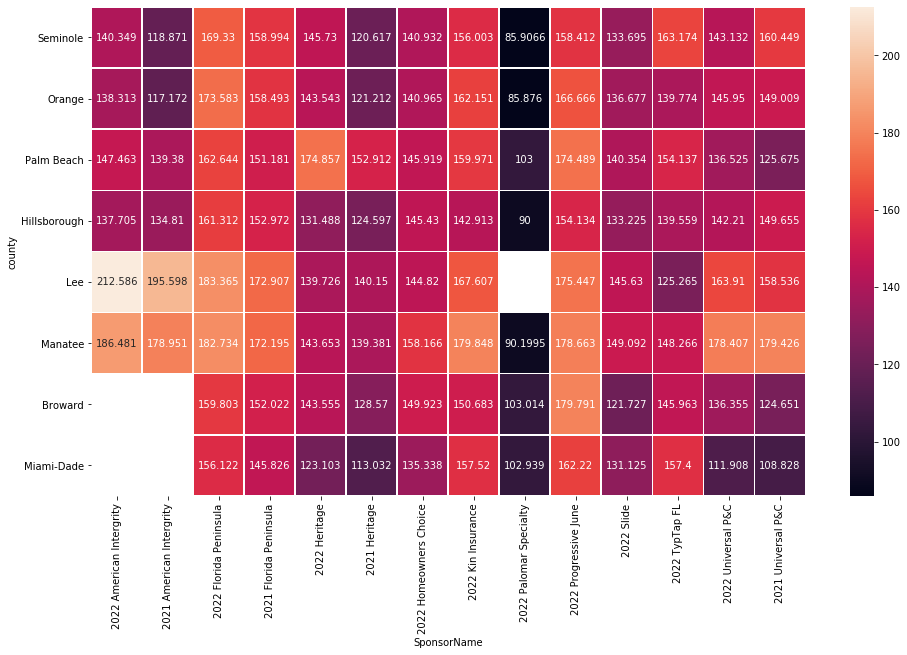

In [63]:
fig, ax = plt.subplots(figsize=(16,9))
sns.heatmap(bldg_pivot, annot=True, linewidths=.5, fmt='g')

In [90]:
bldg_pivot.to_excel(file_path, sheet_name='YoY Comparison')

In [91]:
# total_df.to_excel(file_path, sheet_name= 'Sponsor wise Total TIV')

workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
total_df.to_excel(writer, 'Sponsor wise Total TIV')
writer.save()
writer.close()

In [92]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name='YoY Comparison')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
bldgvaluePct_pivot.to_excel(writer, 'YoY Comparison', startrow=len(reader)+ 3)
writer.save()
writer.close()

In [93]:
workbook = openpyxl.load_workbook(file_path)
writer = pandas.ExcelWriter(file_path, engine='openpyxl')
reader = pandas.read_excel(file_path, sheet_name='YoY Comparison')
writer.book = workbook
writer.sheets = dict((ws.title, ws) for ws in workbook.worksheets)
LocCountPct_pivot.to_excel(writer, 'YoY Comparison', startrow=len(reader)+ 3)
writer.save()
writer.close()

In [308]:
## To Append the data into exsiting sheet

writer = pandas.ExcelWriter('demo.xlsx', engine='openpyxl')

## Read the Existing File

reader = pandas.read_excel(r'demo.xlsx')

df.to_excel(writer, index=False, header=False, startrow=len(reader)+1)

[Errno 2] No such file or directory: 'demo.xlsx'


FileNotFoundError: [Errno 2] No such file or directory: 'demo.xlsx'